<a href="https://colab.research.google.com/github/ollihansen90/zeugs/blob/main/Image_kmeans_NG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(690, 530, 3)


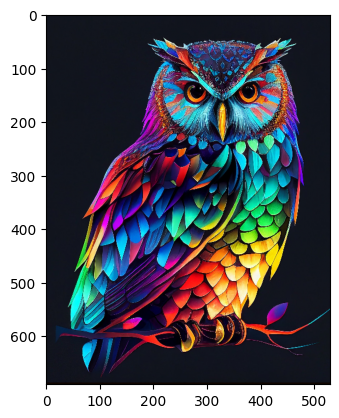

In [ ]:
import numpy as np
from skimage import io
import matplotlib.pyplot as plt

class kMeans():
    def __init__(self, num_cluster=5, data=None):
        self.codebooks = 3*np.random.rand(num_cluster, 2)-1.5
        if data is not None:
            self.init_codes(data)

    def init_codes(self, data):
        self.codebooks = data[np.random.permutation(len(data))][:len(self.codebooks)]

    def update(self, x):
        out = self.pred(x)
        for c in range(len(self.codebooks)):
            if len(x[out==c])==0:
                continue
            self.codebooks[c] = np.mean(x[out==c], axis=0)

    def pred(self, x):
        dists = np.sqrt(np.sum((x[:,None]-self.codebooks[None])**2, axis=-1)).T
        return np.argmin(dists, axis=0)

    def fit(self, x, verbose=False, max_it=100):
        self.init_codes(x)
        alt = 0
        for i in range(max_it):
            alt = self.codebooks.copy()
            self.update(x)
            dists = np.sum((alt-self.codebooks)**2, axis=-1)
            if np.max(dists)==0:
                break
        if verbose:
            print(f"{len(self.codebooks)} Zentren wurden in {i+1} Schritten gelernt. Fehler: {self.fehler(x)}")

    def fehler(self, x):
        dists = np.sqrt(np.sum((x[:,None]-self.codebooks[None])**2, axis=-1)).T
        d = np.argmin(dists, axis=0)
        out = 0
        for j,i in enumerate(d):
            out += dists[i,j]
        return out/len(x)

every = 3
testimg = io.imread("https://i.etsystatic.com/42680663/r/il/d43c98/4964225941/il_1588xN.4964225941_f7nu.jpg").astype(float)[::every,::every]/256
#testimg = io.imread("https://vstudia.de/wp-content/uploads/2021/06/3.jpg").astype(float)[::5,::5]/256
testimg/=np.max(testimg)
print(testimg.shape)
plt.figure()
plt.imshow(testimg)
plt.show()

In [ ]:
1.3e6*4*3*4/1024/1024

59.50927734375

In [ ]:
!wget https://i.etsystatic.com/42680663/r/il/d43c98/4964225941/il_1588xN.4964225941_f7nu.jpg

--2025-08-25 13:15:29--  https://i.etsystatic.com/42680663/r/il/d43c98/4964225941/il_1588xN.4964225941_f7nu.jpg
Resolving i.etsystatic.com (i.etsystatic.com)... 151.101.1.224, 151.101.65.224, 151.101.129.224, ...
Connecting to i.etsystatic.com (i.etsystatic.com)|151.101.1.224|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635568 (621K) [image/jpeg]
Saving to: ‘il_1588xN.4964225941_f7nu.jpg’

il_1588xN.496422594 100%[===================>] 620.67K  --.-KB/s    in 0.009s  

2025-08-25 13:15:29 (68.9 MB/s) - ‘il_1588xN.4964225941_f7nu.jpg’ saved [635568/635568]



torch.Size([2070, 1588, 3])


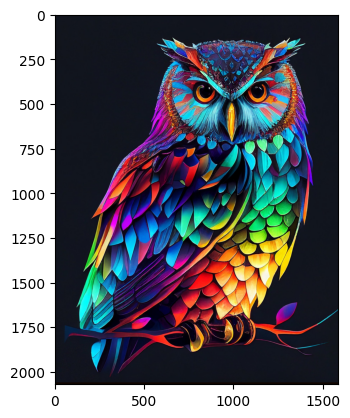

In [ ]:
import torch
import matplotlib.pyplot as plt

class kMeans():
    def __init__(self, num_cluster=5, data=None):
        self.codebooks = 3*torch.rand(num_cluster, 2)-1.5
        if data is not None:
            self.init_codes(data)

    def init_codes(self, data):
        self.codebooks = data[torch.randperm(len(data))][:len(self.codebooks)]

    def update(self, x):
        out = self.pred(x)
        for c in range(len(self.codebooks)):
            if len(x[out==c])==0:
                continue
            self.codebooks[c] = torch.mean(x[out==c], dim=0)

    def pred(self, x):
        dists = torch.sqrt(torch.sum((x[:,None]-self.codebooks[None])**2, dim=-1)).T
        return torch.argmin(dists, dim=0)

    def fit(self, x, verbose=False, max_it=100):
        self.init_codes(x)
        alt = 0
        for i in range(max_it):
            alt = self.codebooks.clone()
            self.update(x)
            dists = torch.sum((alt-self.codebooks)**2, dim=-1)
            if torch.max(dists)==0:
                break
        if verbose:
            print(f"{len(self.codebooks)} Zentren wurden in {i+1} Schritten gelernt. Fehler: {self.fehler(x)}")

    def fehler(self, x):
        dists = torch.sqrt(torch.sum((x[:,None]-self.codebooks[None])**2, dim=-1)).T
        d = torch.argmin(dists, dim=0)
        out = 0
        for j,i in enumerate(d):
            out += dists[i,j]
        return out/len(x)

    def to(self, device):
        self.codebooks.to(device)

testimg = torch.tensor(plt.imread("il_1588xN.4964225941_f7nu.jpg")).float()[::1,::1]#/256
#testimg = io.imread("https://vstudia.de/wp-content/uploads/2021/06/3.jpg").astype(float)[::5,::5]/256
testimg/=torch.max(testimg)
print(testimg.shape)
plt.figure()
plt.imshow(testimg)
plt.show()

In [ ]:
import time
device = "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"

fulldata = testimg.reshape(-1, 3).to(device)
print(fulldata.shape)
data = torch.unique(fulldata, dim=0)
#data = fulldata[::100]
print(data.shape)
kmeans1 = kMeans(num_cluster=3, data=data)
kmeans1.to(device)
kmeans2 = kMeans(num_cluster=3, data=data)
kmeans2.to(device)
print(kmeans1.codebooks.shape)
start = time.time()
kmeans1.fit(data[::100], verbose=True, max_it=100)
kmeans2.fit(data, verbose=True, max_it=100)
print(time.time()-start, "Sekunden")

torch.Size([3287160, 3])
torch.Size([768326, 3])
torch.Size([3, 3])
3 Zentren wurden in 25 Schritten gelernt. Fehler: 0.3193953335285187
3 Zentren wurden in 26 Schritten gelernt. Fehler: 0.3187048137187958
21.341638803482056 Sekunden


tensor([[0.2338, 0.7060, 0.7341],
        [0.2603, 0.1768, 0.3297],
        [0.8422, 0.4770, 0.3209]], device='cuda:0')


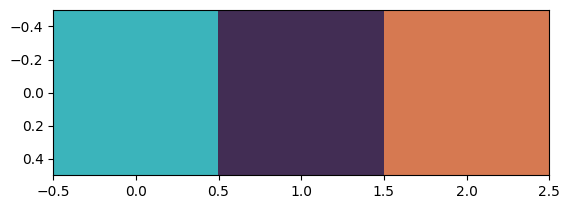

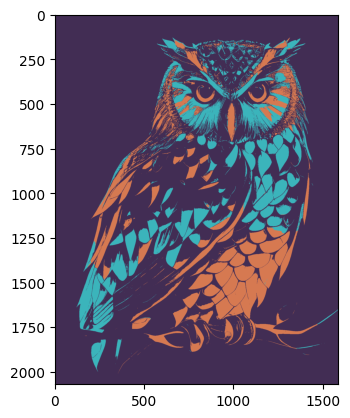

tensor([[0.8445, 0.4750, 0.3259],
        [0.2334, 0.7026, 0.7294],
        [0.2620, 0.1734, 0.3235]], device='cuda:0')


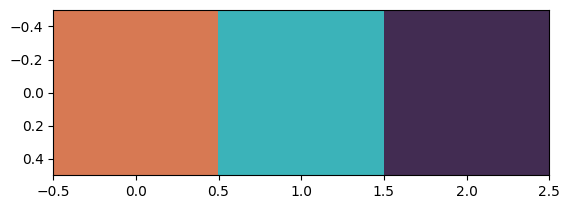

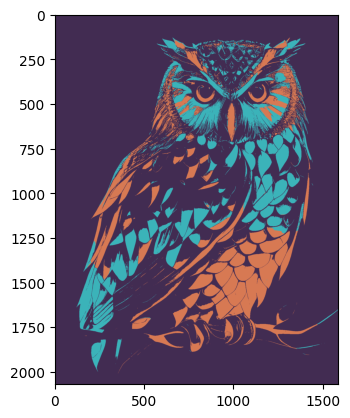

In [ ]:
kmeans = kmeans1
print(kmeans.codebooks)
clusters = kmeans.pred(fulldata).reshape(testimg.shape[:2])
plt.figure()
plt.imshow(kmeans.codebooks[None].cpu().numpy())
plt.show()
clustered = torch.zeros_like(testimg).to(device)
for i in range(len(kmeans.codebooks)):
    clustered[clusters==i] = kmeans.codebooks[i]
plt.figure()
plt.imshow(clustered.cpu().numpy())
plt.show()

kmeans = kmeans2
print(kmeans.codebooks)
clusters = kmeans.pred(fulldata).reshape(testimg.shape[:2])
plt.figure()
plt.imshow(kmeans.codebooks[None].cpu().numpy())
plt.show()
clustered = torch.zeros_like(testimg).to(device)
for i in range(len(kmeans.codebooks)):
    clustered[clusters==i] = kmeans.codebooks[i]
plt.figure()
plt.imshow(clustered.cpu().numpy())
plt.show()

In [ ]:
print(torch.sqrt(torch.sum((kmeans1.codebooks[:,None]-kmeans2.codebooks[None])**2, dim=-1)).T)

tensor([[0.7701, 0.6560, 0.0059],
        [0.0058, 0.6610, 0.7671],
        [0.6731, 0.0073, 0.6549]], device='cuda:0')


In [ ]:
0.0897984504699707*9000/60/60

0.22449612617492676